In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import time

In [2]:
valid = pd.read_csv('../../../../results/translation_efficiency/training_data/2_bin/valid.tsv', sep='\t')
scores = pd.read_csv('../../../../results/translation_efficiency/training_data/2_bin/models/pcv2-l48-d1536/valid_predictions.tsv', sep='\t')
valid['scores'] = scores['probability_positive']
valid.head()

,gene,chr,strand,TPM,seq,label,scores
0,AT1G01030,1,-,1.088918,ATATACATATATAGTTTTCTTCCGATTCTAGGGTTTTCATATTTCC...,1,0.496288
1,AT1G01070,1,-,5.516785,ATAAAAAATTAAAGGGTGTAGTATGAAGTGCTTGATTAACTTTTCA...,1,0.556555
2,AT1G01100,1,-,323.478734,TAAATATGTCAAATGAAGAATTATGTTACTAGTGCGAAAAGGACAT...,1,0.903292
3,AT1G01120,1,-,95.581248,ATTAACAAGTTATGTTGTTTATCAAAAACTTCAAAAAAAAAAAAAA...,1,0.783045
4,AT1G01200,1,-,2.641557,TGGAGCATAAGAGCTTTTTTAGGTGGTCTCCAGACAAATCGTGGGT...,1,0.693615


In [3]:
ism = pd.read_csv('../../../../results/translation_efficiency/training_data/2_bin/valid_ism.tsv', sep='\t')
ism_scores = pd.read_csv('../../../../results/translation_efficiency/training_data/2_bin/models/pcv2-l48-d1536/valid_ism_scores.tsv', sep='\t')
ism['scores'] = ism_scores['probability_positive']
ism.head()

,gene,original_index,pos,original_base,mutated_base,seq,scores
0,AT1G01030,0,-100,T,A,ATATACATATATAGTTTTCTTCCGATTCTAGGGTTTTCATATTTCC...,0.495933
1,AT1G01030,0,-100,T,C,ATATACATATATAGTTTTCTTCCGATTCTAGGGTTTTCATATTTCC...,0.504070
2,AT1G01030,0,-100,T,G,ATATACATATATAGTTTTCTTCCGATTCTAGGGTTTTCATATTTCC...,0.498618
3,AT1G01030,0,-99,T,A,ATATACATATATAGTTTTCTTCCGATTCTAGGGTTTTCATATTTCC...,0.494417
4,AT1G01030,0,-99,T,C,ATATACATATATAGTTTTCTTCCGATTCTAGGGTTTTCATATTTCC...,0.504719


In [4]:
positive_indices = valid[valid['scores'] > 0.8].index
negative_indices = valid[valid['scores'] < 0.7].index

print(f"Positive sequences (score > 0.8): {len(positive_indices)}")
print(f"Negative sequences (score < 0.7): {len(negative_indices)}")

# Initialize dictionaries for both groups
results = {}
for group_name, indices in [('positive', positive_indices), ('negative', negative_indices)]:
    position_importance = {}
    nucleotide_contributions = {}
    
    processed = 0
    for idx in indices:
        if idx not in ism['original_index'].values:
            continue
            
        group = ism[ism['original_index'] == idx]
        original_score = valid.loc[idx, 'scores']
        
        for _, row in group.iterrows():
            pos = row['pos']  # Position relative to ATG (-100 to -1)
            mut_base = row['mutated_base']
            
            # Convert probabilities to log-odds
            original_logodds = np.log2(original_score / (1 - original_score + 1e-8))
            mutated_logodds = np.log2(row['scores'] / (1 - row['scores'] + 1e-8))
            
            delta_logodds = mutated_logodds - original_logodds  # Signed log-odds difference
            abs_delta_logodds = abs(delta_logodds)  # Absolute log-odds difference
            
            # Overall position importance (absolute log-odds)
            if pos not in position_importance:
                position_importance[pos] = []
            position_importance[pos].append(abs_delta_logodds)
            
            # Nucleotide-specific contribution (signed log-odds)
            if pos not in nucleotide_contributions:
                nucleotide_contributions[pos] = {'A': [], 'C': [], 'G': [], 'T': []}
            nucleotide_contributions[pos][mut_base].append(delta_logodds)
        
        processed += 1
        if processed % 500 == 0:
            print(f"Processed {processed} {group_name} sequences...")
    
    print(f"Finished processing {processed} {group_name} sequences")
    
    # Calculate statistics for this group
    pos_stats = {}
    for pos, scores in position_importance.items():
        if scores:  # Only if we have data for this position
            pos_stats[pos] = {
                'mean': np.mean(scores),
                'std': np.std(scores),
                'median': np.median(scores),
                'count': len(scores)
            }
    
    nucleotide_stats = {}
    for pos in nucleotide_contributions:
        nucleotide_stats[pos] = {}
        for base in ['A', 'C', 'G', 'T']:
            if nucleotide_contributions[pos][base]:
                nucleotide_stats[pos][base] = np.mean(nucleotide_contributions[pos][base])
            else:
                nucleotide_stats[pos][base] = 0.0
    
    results[group_name] = (pos_stats, nucleotide_stats)


Positive sequences (score > 0.8): 2084
Negative sequences (score < 0.7): 2830
Processed 500 positive sequences...
Processed 1000 positive sequences...
Processed 1500 positive sequences...
Processed 2000 positive sequences...
Finished processing 2084 positive sequences
Processed 500 negative sequences...
Processed 1000 negative sequences...
Processed 1500 negative sequences...
Processed 2000 negative sequences...
Processed 2500 negative sequences...
Finished processing 2830 negative sequences


In [5]:
results

{'positive': ({-100: {'mean': 0.06169402658839383,
    'std': 0.10669361650711355,
    'median': 0.02428959022908317,
    'count': 6252},
   -99: {'mean': 0.05818702875225781,
    'std': 0.09998163807625997,
    'median': 0.023429268988519603,
    'count': 6252},
   -98: {'mean': 0.05689889460314936,
    'std': 0.09834105091747487,
    'median': 0.022434671043627175,
    'count': 6252},
   -97: {'mean': 0.05865197927307917,
    'std': 0.10528424805557449,
    'median': 0.022815830495099387,
    'count': 6252},
   -96: {'mean': 0.055470788725805846,
    'std': 0.09354268591809063,
    'median': 0.021944183185430566,
    'count': 6252},
   -95: {'mean': 0.054796727820653895,
    'std': 0.08841394701198443,
    'median': 0.02261232426594839,
    'count': 6252},
   -94: {'mean': 0.05455679391407108,
    'std': 0.09085801228719909,
    'median': 0.02208000368173435,
    'count': 6252},
   -93: {'mean': 0.05449132035511504,
    'std': 0.09177241069535869,
    'median': 0.022087661003387993,


In [8]:
pos_importance_pos, nucleotide_stats_pos = results['positive']
pos_importance_neg, nucleotide_stats_neg = results['negative']

In [9]:
pos_df_pos = pd.DataFrame(pos_importance_pos).T
pos_df_pos.index.name = 'position'
pos_df_pos = pos_df_pos.reset_index().sort_values('position')

nucleotide_df_pos = pd.DataFrame(nucleotide_stats_pos).T
nucleotide_df_pos.index.name = 'position'
nucleotide_df_pos = nucleotide_df_pos.reset_index().sort_values('position')

# Negative group DataFrames
pos_df_neg = pd.DataFrame(pos_importance_neg).T
pos_df_neg.index.name = 'position'
pos_df_neg = pos_df_neg.reset_index().sort_values('position')

nucleotide_df_neg = pd.DataFrame(nucleotide_stats_neg).T
nucleotide_df_neg.index.name = 'position'
nucleotide_df_neg = nucleotide_df_neg.reset_index().sort_values('position')

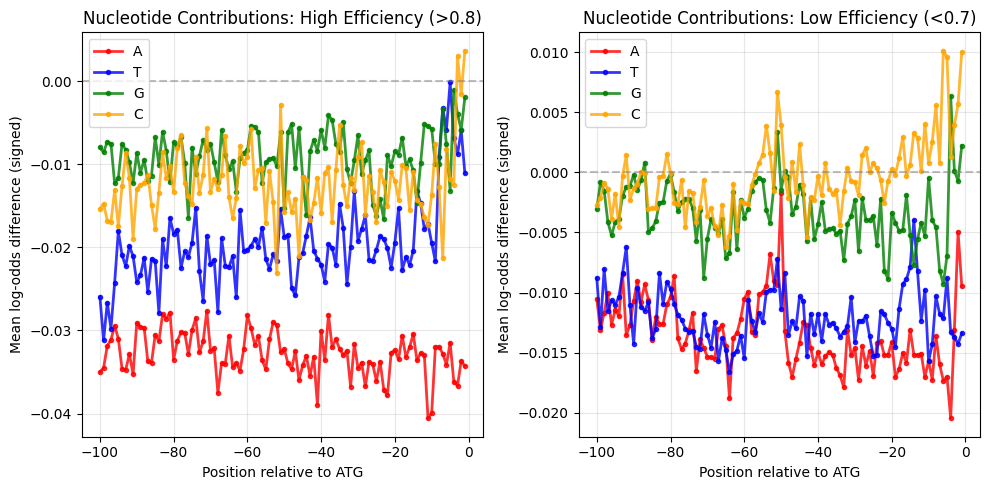

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
colors = {'A': 'red', 'T': 'blue', 'G': 'green', 'C': 'orange'}

for base in ['A', 'T', 'G', 'C']:
    axes[0].plot(nucleotide_df_pos['position'], nucleotide_df_pos[base], 'o-', 
                linewidth=2, markersize=3, color=colors[base], label=f'{base}', alpha=0.8)
axes[0].set_xlabel('Position relative to ATG')
axes[0].set_ylabel('Mean log-odds difference (signed)')

axes[0].set_title('Nucleotide Contributions: High Efficiency (>0.8)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

for base in ['A', 'T', 'G', 'C']:
    axes[1].plot(nucleotide_df_neg['position'], nucleotide_df_neg[base], 'o-', 
                   linewidth=2, markersize=3, color=colors[base], label=f'{base}', alpha=0.8)
axes[1].set_xlabel('Position relative to ATG')
axes[1].set_ylabel('Mean log-odds difference (signed)')
axes[1].set_title('Nucleotide Contributions: Low Efficiency (<0.7)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('nucleotide_contributions.pdf', dpi=300, bbox_inches='tight')
plt.show()